# Regressão Logística I
## Tarefa I

Neste exercício vamos trabalhar com a base "Heart Disease Data Set" disponível no site do [UCI](https://archive.ics.uci.edu/ml/datasets/heart+disease).

Temos 303 indivíduos e vamos utilizar 13 variáveis disponíveis para prever a presença de doença cardíaca na variável ```num```(a 14$^a$ variável).

A descrição das variáveis está recortada abaixo:
- age: idade do paciente em anos
- sex: sexo (1 = male; 0 = female)  
- cp: tipo de dor no peito
  - 1: angina típica
  - 2: angina atípica
  - 3: dor não-angina
  - 4: assintomático
- trestbps: pressão sanguínea em repouso (em mm Hg na admissão ao hospital
- chol: colesterol sérico em mg/dl
- fbs: (açúcar no sangue em jejum > 120 mg/dl) (1 = True; 0 = False)
- restecg: resultados eletrocardiográficos em repouso
  - 0: normal
  - 1: tendo anormalidade da onda ST-T (Inversões de onda T e / ou ST com elevação ou depressão de > 0.05 mV)
  - 2: mostrando hipertrofia ventricular esquerda provável ou definitiva pelos critérios de Estes
- thalach: frequência cardíaca máxima alcançada
- exang: angina induzida por exercício(1 = sim; 0 = não)
- oldpeak = Depressão de ST induzida por exercício em relação ao repouso
- slope: Depressão de ST induzida por exercício em relação ao repouso
  - 1: inclinação ascendente
  - 2: estável
  - 3: inclinação descendente
- ca: número de vasos principais (0-3) coloridos por fluorosopia
- thal: 3 = normal; 6 = defeito corrigido; 7 = defeito reversível
- num: diagnóstico de doença cardíaga (status de doença angiográfica)

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import statsmodels.formula.api as smf

In [4]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

df = pd.read_csv(url, 
                 names=['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                        'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'])
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [7]:
df['flag_doente'] = (df['num'] != 0).astype('int64')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,flag_doente
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2,1
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3,1
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1,1


1. Monte uma bivariada para a variável ```sex``` com as seguintes estatísticas:

- Número de *saudáveis*
- Número de *doentes*
- Total
- Quantidade média de doentes
- *Odds*
- *Odds ratio* (Use o total como referência)
- Logito (LOG(*Odds*))
- O LOG do *Odds ratio* (com o total como referência) é chamado de *Weight of Evidence* (WOE). Calcule-o.

In [10]:
# Tabela bivariada da variável sex

# quantidade de saudáveis e doentes
tab = df.pivot_table(index='sex',
                     columns='flag_doente',
                     aggfunc='size',
                     fill_value=0)

# renomeando colunas
tab.columns = ['Saudaveis', 'Doentes']

# total
tab['Total'] = tab['Saudaveis'] + tab['Doentes']

# média de doentes
tab['Media_doentes'] = tab['Doentes'] / tab['Total']

# odds
tab['Odds'] = tab['Doentes'] / tab['Saudaveis']

# odds total da base
odds_total = df['flag_doente'].sum() / (df.shape[0] - df['flag_doente'].sum())

# odds ratio
tab['Odds_ratio'] = tab['Odds'] / odds_total

# logito
tab['Logito'] = np.log(tab['Odds'])

# Weight of Evidence (WOE)
tab['WOE'] = np.log(tab['Odds_ratio'])

tab

,Saudaveis,Doentes,Total,Media_doentes,Odds,Odds_ratio,Logito,WOE
sex,,,,,,,,
0.0,72,25,97,0.257732,0.347222,0.409672,-1.05779,-0.892398
1.0,92,114,206,0.553398,1.239130,1.461996,0.21441,0.379802


2. Monte uma bivariada para a variável ```age``` com as seguintes estatísticas:
- Categorize a variável em 5 grupos
- Calcule as mesmas quantidades calculadas no execício anterior
- Calcule também o valor médio da variável ```age```

In [19]:
# Criando 5 faixas para idade
df['faixa_idade'] = pd.qcut(df['age'], 5)

# Tabela bivariada
tab_age = df.pivot_table(index='faixa_idade',
                         columns='flag_doente',
                         aggfunc='size',
                         fill_value=0,
                         observed=False)

# Renomeando colunas
tab_age.columns = ['Saudaveis', 'Doentes']

# Total
tab_age['Total'] = tab_age['Saudaveis'] + tab_age['Doentes']

# Média de doentes
tab_age['Media_doentes'] = tab_age['Doentes'] / tab_age['Total']

# Odds
tab_age['Odds'] = tab_age['Doentes'] / tab_age['Saudaveis']

# Odds total da base
odds_total = df['flag_doente'].sum() / (
    df.shape[0] - df['flag_doente'].sum()
)

# Odds Ratio
tab_age['Odds_ratio'] = tab_age['Odds'] / odds_total

# Logito
tab_age['Logito'] = np.log(tab_age['Odds'])

# WOE
tab_age['WOE'] = np.log(tab_age['Odds_ratio'])

# Média da idade em cada faixa
media_idade = df.groupby('faixa_idade',
                         observed=False)['age'].mean()

# Adicionando na tabela
tab_age['Media_idade'] = media_idade

tab_age

,Saudaveis,Doentes,Total,Media_doentes,Odds,Odds_ratio,Logito,WOE,Media_idade
faixa_idade,,,,,,,,,
"(28.999, 45.0]",47,16,63,0.253968,0.340426,0.401653,-1.077559,-0.912166,41.222222
"(45.0, 53.0]",42,22,64,0.343750,0.523810,0.618020,-0.646627,-0.481235,50.000000
"(53.0, 58.0]",32,39,71,0.549296,1.218750,1.437950,0.197826,0.363218,56.211268
"(58.0, 62.0]",13,32,45,0.711111,2.461538,2.904261,0.900787,1.066179,60.355556
"(62.0, 77.0]",30,30,60,0.500000,1.000000,1.179856,0.000000,0.165392,66.516667


3. Visualize a informação da bivariada construída acima através de um gráfico da sua escolha.

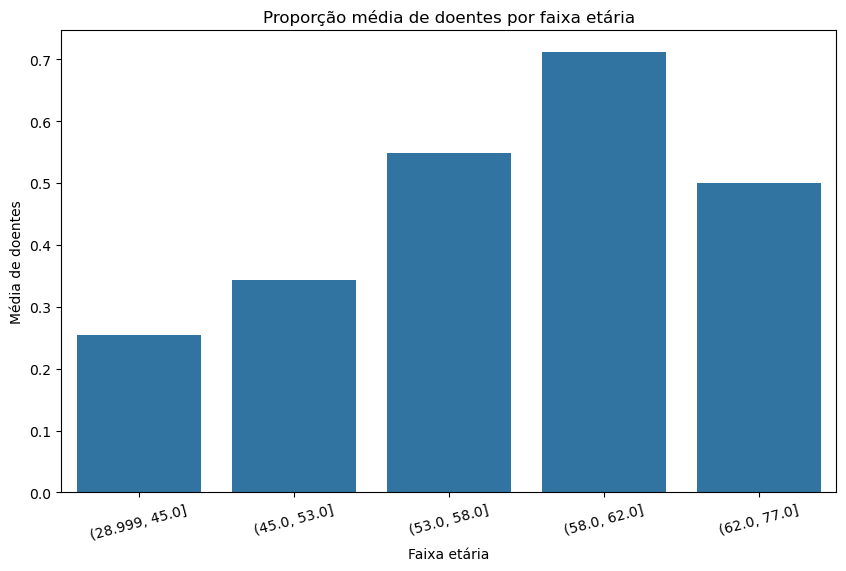

In [22]:
# Resetando índice para facilitar o gráfico
grafico_age = tab_age.reset_index()

# Criando gráfico
plt.figure(figsize=(10,6))

sns.barplot(data=grafico_age,
            x='faixa_idade',
            y='Media_doentes')

# Ajustes visuais
plt.title('Proporção média de doentes por faixa etária')
plt.xlabel('Faixa etária')
plt.ylabel('Média de doentes')

plt.xticks(rotation=15)

plt.show()